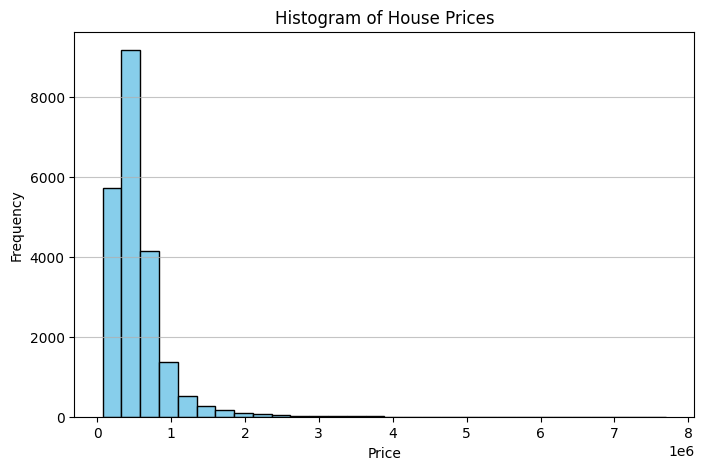

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('house_prices.csv')


plt.figure(figsize=(8, 5))
plt.hist(df['price'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()



### Task 1 Breakdown: House Price Histogram Analysis

- **Is the distribution normal, skewed left, or skewed right?**
  - The distribution is **skewed right** (most houses are cheaper, a few are very expensive).

- **Are there extreme values?**
  - Yes, there are **extreme values** (some houses cost much more than most others).


### Task 2 Breakdown: Boxplot Analysis

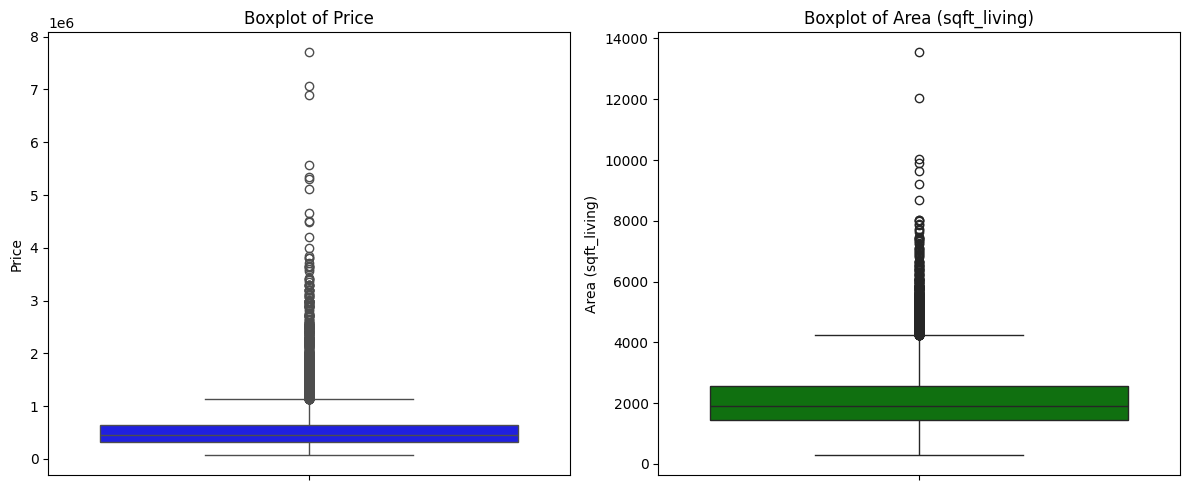

In [5]:
# Task 2: Boxplot for Price and Area
import seaborn as sns
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['price'], color='blue')
plt.title('Boxplot of Price')
plt.ylabel('Price')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['sqft_living'], color='green')  # 'sqft_living' is the area
plt.title('Boxplot of Area (sqft_living)')
plt.ylabel('Area (sqft_living)')
plt.tight_layout()
plt.show()



- **Price:** Most house prices are in a lower range, but there are some houses that are much more expensive (outliers).
- **Area (sqft_living):** Most houses have a moderate area, but a few houses are much larger than the rest (outliers).

Both boxplots show that there are some extreme values (outliers) that are much higher than most of the data.

### Task 3 Breakdown: Bar Chart Analysis




C:\Users\NAKSUU\AppData\Local\Temp\ipykernel_20036\1685786805.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_by_bedrooms.index, y=avg_price_by_bedrooms.values, palette='viridis')


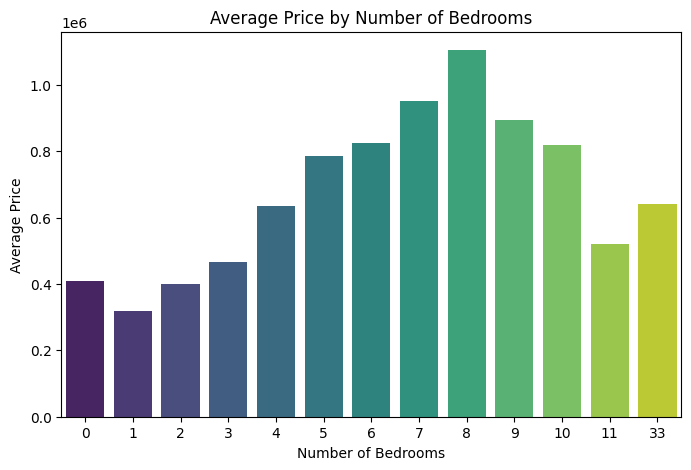

In [6]:
# Task 3: Bar Chart for Average Price by Number of Bedrooms
avg_price_by_bedrooms = df.groupby('bedrooms')['price'].mean().sort_index()
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_price_by_bedrooms.index, y=avg_price_by_bedrooms.values, palette='viridis')
plt.title('Average Price by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Average Price')
plt.show()

- **Does price increase with bedrooms?**
  - In general, the average price increases as the number of bedrooms goes up, especially from 1 to 8 bedrooms. However, for very high numbers of bedrooms, the average price does not always keep increasing and can even decrease. This may be due to outliers or unusual properties.

- **Is it always increasing?**
  - No, it is not always increasing. While the average price generally goes up as the number of bedrooms increases (from 1 to 8 bedrooms), for houses with very high numbers of bedrooms, the average price sometimes goes down. This means the relationship is not perfectly increasing for all bedroom counts.

### Task 4: Scatter Plot
- Plot:
  - Area vs Price
  - Add regression line (Seaborn)



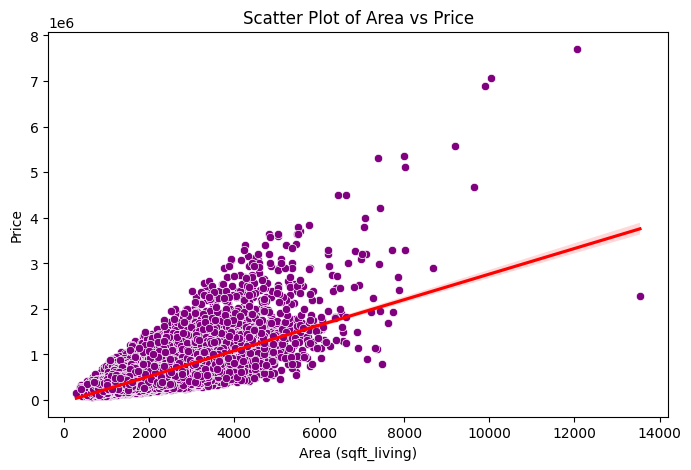

In [7]:
# Task 4: Scatter Plot for Area vs Price with Regression Line
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['sqft_living'], y=df['price'], color='purple')
sns.regplot(x=df['sqft_living'], y=df['price'], scatter=False, color='red')
plt.title('Scatter Plot of Area vs Price')
plt.xlabel('Area (sqft_living)')
plt.ylabel('Price')
plt.show()



- **Is the relationship positive or negative?**
  - The relationship is positive: as area increases, price also tends to increase.

- **Is the correlation strong or weak?**
  - The correlation is moderate: the points generally follow the upward trend, but there is a lot of spread.

- **Are there any unusual points?**
  - Yes, there are some unusual points (outliers) where houses have very large areas or very high prices compared to most others.

### Task 5: Heatmap
- Plot a correlation heatmap for the numeric features.



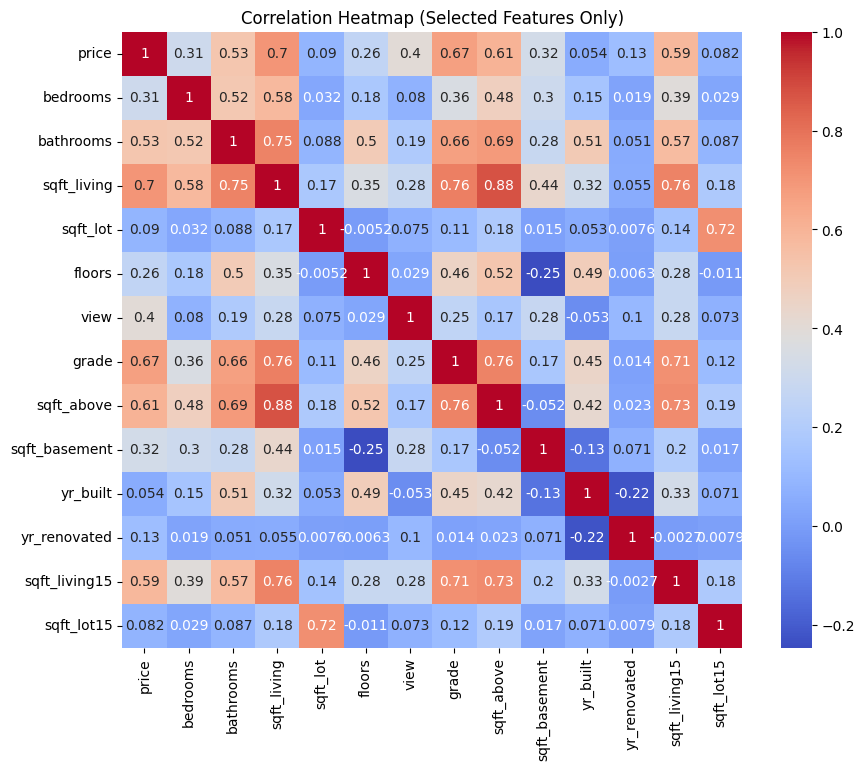

In [8]:
# Task 5: Heatmap
# Remove unnecessary columns
df_clean = df.drop(columns=['id', 'long', 'lat', 'zipcode'], errors='ignore')
# Select only numeric columns
numeric_df = df_clean.select_dtypes(include=['int64', 'float64'])
# Compute correlation
corr = numeric_df.corr()
# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Selected Features Only)')
plt.show()

### Task 5 Breakdown: Heatmap Analysis

- **Which feature is most correlated with price?**
  - sqft_living (area of the house) has the strongest positive correlation with price.

- **Which features are highly correlated with each other?**
  - sqft_living and sqft_above are highly correlated.
  - sqft_living and bathrooms are also strongly correlated.
  - grade is strongly correlated with both price and sqft_living.



### Task 6: Understand Poverty Situation
- Analyze how poverty is distributed across provinces.
- Questions:
  - Are poverty rates evenly distributed?
  - Are there extreme provinces?
  - What does the distribution shape look like?


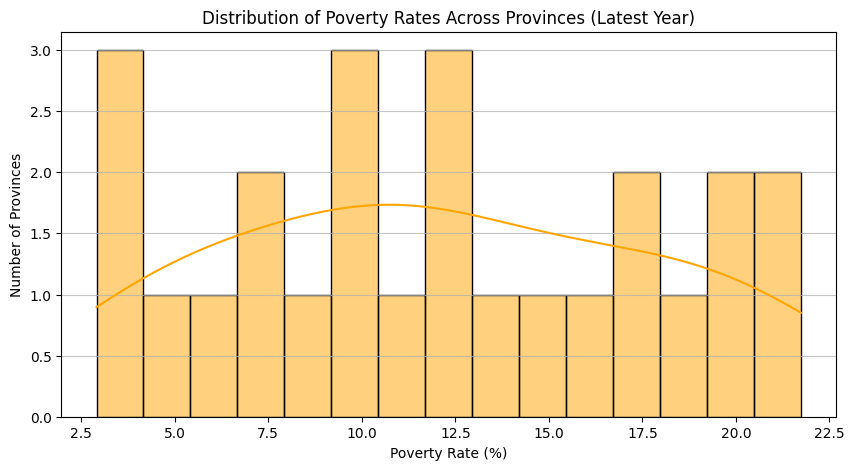

count    25.000000
mean     12.138000
std       5.786195
min       2.910000
25%       7.630000
50%      12.110000
75%      16.910000
max      21.740000
Name: poverty_rate, dtype: float64

In [9]:
# Task 6: Analyze Poverty Rate Distribution Across Provinces
import pandas as pd
poverty_df = pd.read_csv('data.csv')
# Get the latest year for each province
df_latest = poverty_df.sort_values('year').groupby('province').tail(1)
plt.figure(figsize=(10, 5))
sns.histplot(df_latest['poverty_rate'], bins=15, kde=True, color='orange', edgecolor='black')
plt.title('Distribution of Poverty Rates Across Provinces (Latest Year)')
plt.xlabel('Poverty Rate (%)')
plt.ylabel('Number of Provinces')
plt.grid(axis='y', alpha=0.75)
plt.show()
# Show summary statistics
df_latest['poverty_rate'].describe()



- **Are poverty rates evenly distributed?**
  - No, poverty rates are not evenly distributed. Provinces have a wide range of poverty rates.

- **Are there extreme provinces?**
  - Yes, some provinces have much higher or much lower poverty rates than most others (extreme values/outliers).

- **What does the distribution shape look like?**
  - The distribution is spread out and does not follow a perfect bell curve. There are provinces with both very low and very high poverty rates, so the shape is somewhat flat and irregular.

### Task 7: Provincial Comparison
- Compare average income across provinces.



C:\Users\NAKSUU\AppData\Local\Temp\ipykernel_20036\570427402.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_income_usd', y='province', data=latest_income_sorted, palette='coolwarm')


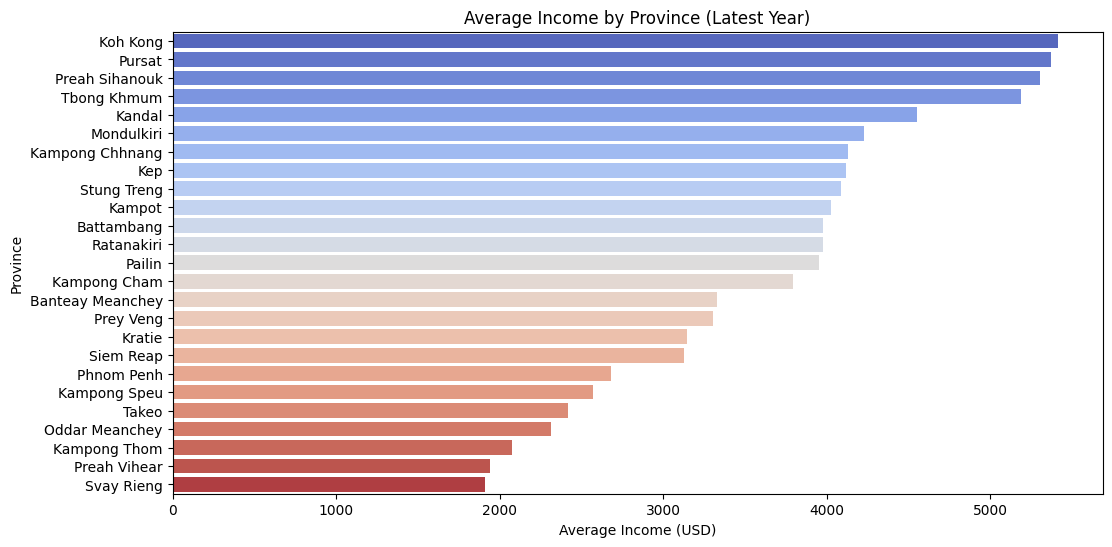

Highest income province: Koh Kong - 5415.25
Lowest income province: Svay Rieng - 1910.57


count      25.000000
mean     3636.933200
std      1079.625801
min      1910.570000
25%      2678.770000
50%      3952.330000
75%      4128.650000
max      5415.250000
Name: avg_income_usd, dtype: float64

In [10]:
# Task 7: Compare Average Income Across Provinces
# Use the latest year for each province
latest_income = poverty_df.sort_values('year').groupby('province').tail(1)
plt.figure(figsize=(12, 6))
latest_income_sorted = latest_income.sort_values('avg_income_usd', ascending=False)
sns.barplot(x='avg_income_usd', y='province', data=latest_income_sorted, palette='coolwarm')
plt.title('Average Income by Province (Latest Year)')
plt.xlabel('Average Income (USD)')
plt.ylabel('Province')
plt.show()
# Show top and bottom provinces
highest = latest_income_sorted.iloc[0][['province', 'avg_income_usd']]
lowest = latest_income_sorted.iloc[-1][['province', 'avg_income_usd']]
print('Highest income province:', highest['province'], '-', highest['avg_income_usd'])
print('Lowest income province:', lowest['province'], '-', lowest['avg_income_usd'])
# Show summary statistics
latest_income['avg_income_usd'].describe()



- **Which provinces are highest and lowest?**
  - The highest average income is in Koh Kong ($5,415.25).
  - The lowest average income is in Svay Rieng ($1,910.57).

- **Is there large inequality?**
  - Yes, there is a large gap between the highest and lowest provinces. The difference is more than double, and the bar chart shows a wide spread of incomes across provinces.

### Task 8: Relationship Exploration
- Investigate the relationship between poverty rate and average income.



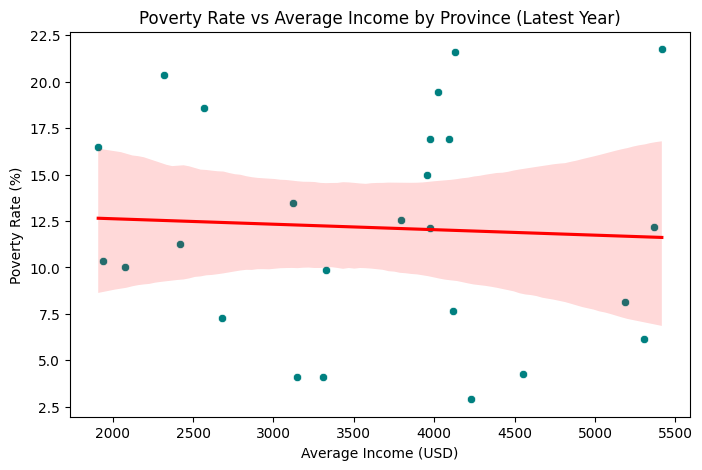

Correlation between average income and poverty rate: -0.054983384390068536


In [11]:
# Task 8: Explore Relationship Between Poverty Rate and Average Income
plt.figure(figsize=(8, 5))
sns.scatterplot(x=latest_income['avg_income_usd'], y=latest_income['poverty_rate'], color='teal')
sns.regplot(x=latest_income['avg_income_usd'], y=latest_income['poverty_rate'], scatter=False, color='red')
plt.title('Poverty Rate vs Average Income by Province (Latest Year)')
plt.xlabel('Average Income (USD)')
plt.ylabel('Poverty Rate (%)')
plt.show()
# Calculate correlation
correlation = latest_income['avg_income_usd'].corr(latest_income['poverty_rate'])
print('Correlation between average income and poverty rate:', correlation)



- **Is there a relationship?**
  - There is almost no clear relationship between average income and poverty rate across provinces.

- **Is it positive or negative?**
  - The relationship is very slightly negative (as income increases, poverty rate tends to decrease a little), but the effect is very weak.

- **Is it strong or weak?**
  - The relationship is very weak. The points are widely scattered and the correlation is close to zero.

- **What is the correlation value?**
  - The correlation between average income and poverty rate is about -0.05.

### Task 9: Education & Poverty
- Explore how literacy rate relates to poverty rate.



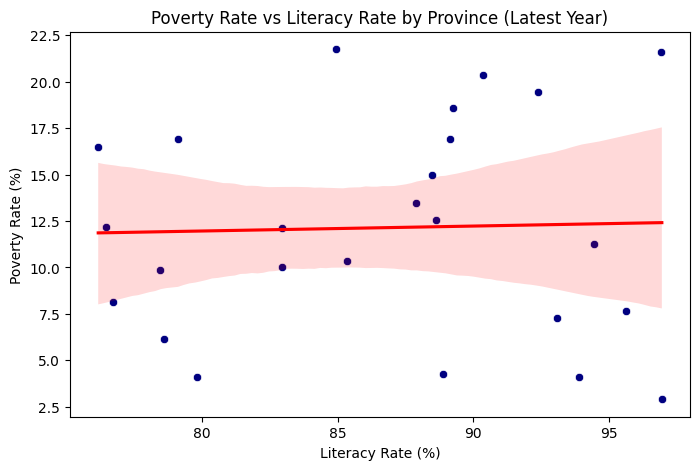

Correlation between literacy rate and poverty rate: 0.031097032923314723


In [12]:
# Task 9: Explore Relationship Between Literacy Rate and Poverty Rate
plt.figure(figsize=(8, 5))
sns.scatterplot(x=latest_income['literacy_rate'], y=latest_income['poverty_rate'], color='navy')
sns.regplot(x=latest_income['literacy_rate'], y=latest_income['poverty_rate'], scatter=False, color='red')
plt.title('Poverty Rate vs Literacy Rate by Province (Latest Year)')
plt.xlabel('Literacy Rate (%)')
plt.ylabel('Poverty Rate (%)')
plt.show()
# Calculate correlation
correlation = latest_income['literacy_rate'].corr(latest_income['poverty_rate'])
print('Correlation between literacy rate and poverty rate:', correlation)



- **Do provinces with higher literacy have lower poverty?**
  - There is almost no relationship. Provinces with higher literacy rates do not necessarily have lower poverty rates.

- **Are there any unusual provinces?**
  - Yes, there are some provinces with high literacy but also high poverty, and some with low literacy but low poverty. These are unusual compared to the general trend.



### Task 10: Economic Trend
- Analyze tourism revenue trends over time for at least 3 provinces.



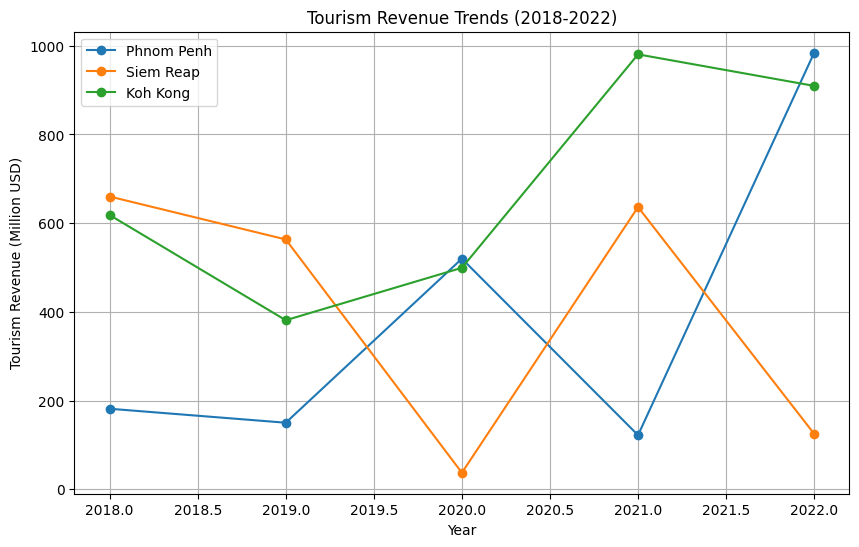

Phnom Penh: Growth = 442.58%, Volatility (std) = 368.45
Siem Reap: Growth = -81.10%, Volatility (std) = 298.90
Koh Kong: Growth = 47.10%, Volatility (std) = 259.24


In [13]:
# Task 10: Tourism Revenue Trends for 3 Provinces
provinces_to_plot = ['Phnom Penh', 'Siem Reap', 'Koh Kong']
plt.figure(figsize=(10, 6))
for province in provinces_to_plot:
    subset = poverty_df[poverty_df['province'] == province]
    plt.plot(subset['year'], subset['tourism_revenue_million'], marker='o', label=province)
plt.title('Tourism Revenue Trends (2018-2022)')
plt.xlabel('Year')
plt.ylabel('Tourism Revenue (Million USD)')
plt.legend()
plt.grid(True)
plt.show()
# Show summary statistics for growth and volatility
for province in provinces_to_plot:
    subset = poverty_df[poverty_df['province'] == province]
    growth = (subset['tourism_revenue_million'].iloc[-1] - subset['tourism_revenue_million'].iloc[0]) / subset['tourism_revenue_million'].iloc[0] * 100
    volatility = subset['tourism_revenue_million'].std()
    print(f"{province}: Growth = {growth:.2f}%, Volatility (std) = {volatility:.2f}")



- **Which province grows fastest?**
  - Phnom Penh grows the fastest, with tourism revenue increasing by over 440% from 2018 to 2022.

- **Which is unstable?**
  - Siem Reap is the most unstable, with large ups and downs and a big drop in 2020.

- **What happened during specific years?**
  - In 2020, Siem Reap's tourism revenue dropped sharply, likely due to the COVID-19 pandemic. Phnom Penh and Koh Kong also show big changes in some years, but Phnom Penh recovers and grows strongly by 2022.

### Task 11: Correlation Matrix
- Plot a correlation matrix for key independent variables.
- Questions:
  - Which two variables have the strongest positive correlation?
  - Which variables show a negative relationship with average income?
  - Is tourism revenue strongly related to unemployment rate?
  - How does unemployment relate to education indicators?
  - Does higher income strongly correspond to better education outcomes?


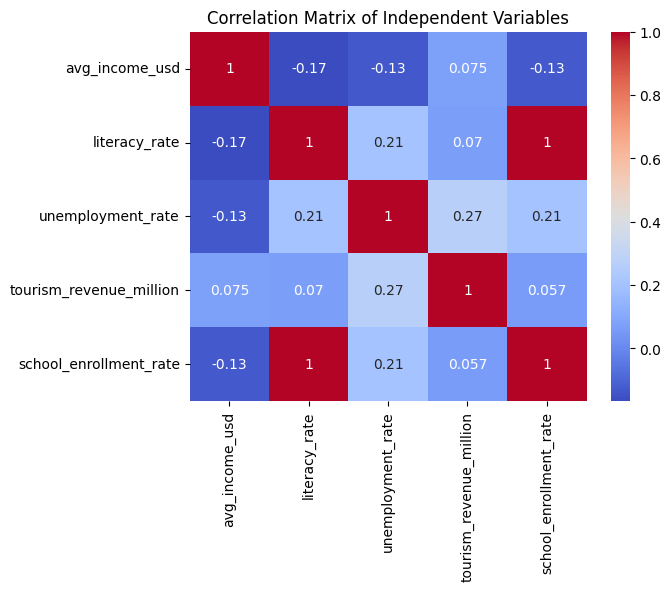

,avg_income_usd,literacy_rate,unemployment_rate,tourism_revenue_million,school_enrollment_rate
avg_income_usd,1.000000,-0.166746,-0.134491,0.074678,-0.129059
literacy_rate,-0.166746,1.000000,0.206060,0.069730,0.996737
unemployment_rate,-0.134491,0.206060,1.000000,0.266309,0.206322
tourism_revenue_million,0.074678,0.069730,0.266309,1.000000,0.057296
school_enrollment_rate,-0.129059,0.996737,0.206322,0.057296,1.000000


In [14]:
# Task 11: Correlation Matrix
corr_matrix = latest_income[['avg_income_usd','literacy_rate','unemployment_rate','tourism_revenue_million','school_enrollment_rate']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Independent Variables')
plt.show()
corr_matrix



- **Which two variables have the strongest positive correlation?**
  - Literacy rate and school enrollment rate (correlation ≈ 1.00).

- **Which variables show a negative relationship with average income?**
  - Literacy rate, unemployment rate, and school enrollment rate all show a weak negative relationship with average income.

- **Is tourism revenue strongly related to unemployment rate?**
  - No, the correlation is weak (≈ 0.27), so there is no strong relationship.

- **How does unemployment relate to education indicators?**
  - Unemployment rate has a weak positive correlation with both literacy rate and school enrollment rate (≈ 0.21).

- **Does higher income strongly correspond to better education outcomes?**
  - No, higher income does not strongly correspond to better education outcomes in this data (correlations are weak and negative).
